# Data transformation project 

영국시장 중고차 가격 데이터

In [380]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import statsmodels.formula.api as smf
import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'AppleGothic'  # 기본 폰트 설정 (macOS)
plt.rcParams['axes.unicode_minus'] = False 


In [357]:

cars = pd.read_csv('cars.csv')
brand = pd.read_csv('brand.csv')

In [358]:
print(cars.info())
print(cars.isnull().any())
print(cars.describe())
display(cars.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3687 entries, 0 to 3686
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              3687 non-null   object 
 1   Price              3687 non-null   int64  
 2   Mileage(miles)     3687 non-null   int64  
 3   Registration_Year  3687 non-null   int64  
 4   Previous Owners    2276 non-null   float64
 5   Fuel type          3687 non-null   object 
 6   Body type          3687 non-null   object 
 7   Engine             3642 non-null   object 
 8   Gearbox            3687 non-null   object 
 9   Doors              3662 non-null   float64
 10  Seats              3652 non-null   float64
 11  Emission Class     3600 non-null   object 
 12  Service history    540 non-null    object 
dtypes: float64(3), int64(3), object(7)
memory usage: 374.6+ KB
None
title                False
Price                False
Mileage(miles)       False
Registration_Year    Fa

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN


주 데이터인 cars는 13개 변수, 약 3687개 데이터

변수 설명

title 
- 차 제조사, 이름

price : 수치형
- 차 가격 (영국 파운드 겠죠)

Mileage : 수치형
- 마일리지 거리 (mile) 1 mile = 1.61 km 

Registraion_year  : 수치형? 순서형?
- 연식

Previous Owners : 결측값 있음
- 전 주인이 몇명인지 (1~9명까지)

Fuel type : 범주형
- 기름 종류 (하이브리드, 디젤 등등)

Body type : 범주형
- 차체 형태(해치백, SUV, 쿠페, 컨버터블 등)

Engine	: 수치형인데 *.*L 꼴이라 오브젝트 결측값 있음 
- 엔진 용량 

Gearbox	: 범주형
- 기어박스 종류(수동,자동)

Doors : 결측값 있음 
- 문 개수(2,3,4,5개)

Seats : 결측값 있음
- 몇 인승 (2~7인승까지)

Emission Class : 결측값 있음 , 범주형
- 유럽 배출가스 기준 등급 연식에 따라 6등급으로 나눔, 높을수록 최신

Service history : 결측값 있음 , 이진변수
- 점검 및 관리 기록 (Full & 결측)

In [359]:
print(cars['Service history'].value_counts())
print(cars['Body type'].value_counts())
print(cars['Fuel type'].value_counts())
print(cars['Previous Owners'].value_counts())
print(cars['Engine'].value_counts())
print(cars['Emission Class'].value_counts())

print(brand.head())

Service history
Full    540
Name: count, dtype: int64
Body type
Hatchback      2280
SUV             461
Saloon          368
Estate          171
MPV             153
Coupe           139
Convertible     109
Pickup            3
Combi Van         2
Minibus           1
Name: count, dtype: int64
Fuel type
Petrol                   2362
Diesel                   1219
Petrol Hybrid              47
Electric                   31
Petrol Plug-in Hybrid      27
Diesel Hybrid               1
Name: count, dtype: int64
Previous Owners
2.0    594
1.0    523
3.0    475
4.0    360
5.0    208
6.0     60
7.0     39
8.0     12
9.0      5
Name: count, dtype: int64
Engine
1.6L    736
2.0L    553
1.2L    521
1.4L    421
1.0L    326
1.5L    294
1.3L    170
1.8L    158
3.0L     79
2.2L     75
2.1L     63
1.1L     39
1.7L     35
2.5L     33
1.9L     31
2.4L     28
0.9L     15
2.7L     11
3.5L     10
3.2L      7
3.7L      5
4.4L      5
2.3L      4
2.6L      4
4.2L      4
5.0L      3
2.8L      3
0.8L      2
4.3L      

보조 데이터인 brand 데이터는 48개 제조사, 국적으로 구성
- 제조국 별로 가격?도 볼 수 있을 것 같음


1. merge 함수 써서 제조사 별로 국적도 추가

소문자 vs 대문자로 충돌 가능하니 모두 대문자로 올려서 병합해주기
- 정상적으로 병합 완료 

In [360]:
brand['Title'] = brand['title'].str.upper()
cars['Title'] = cars['title'].str.split(' ', n=1).str[0].str.upper()
data = pd.merge(left=cars, right=brand, on='Title', how='left')
data.head()

,title_x,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,Title,title_y,country
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN,SKODA,skoda,Czech Republic
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full,VAUXHALL,vauxhall,United Kingdom
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN,HYUNDAI,hyundai,South Korea
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full,MINI,mini,United Kingdom
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN,VAUXHALL,vauxhall,United Kingdom


<Axes: xlabel='Doors', ylabel='Count'>

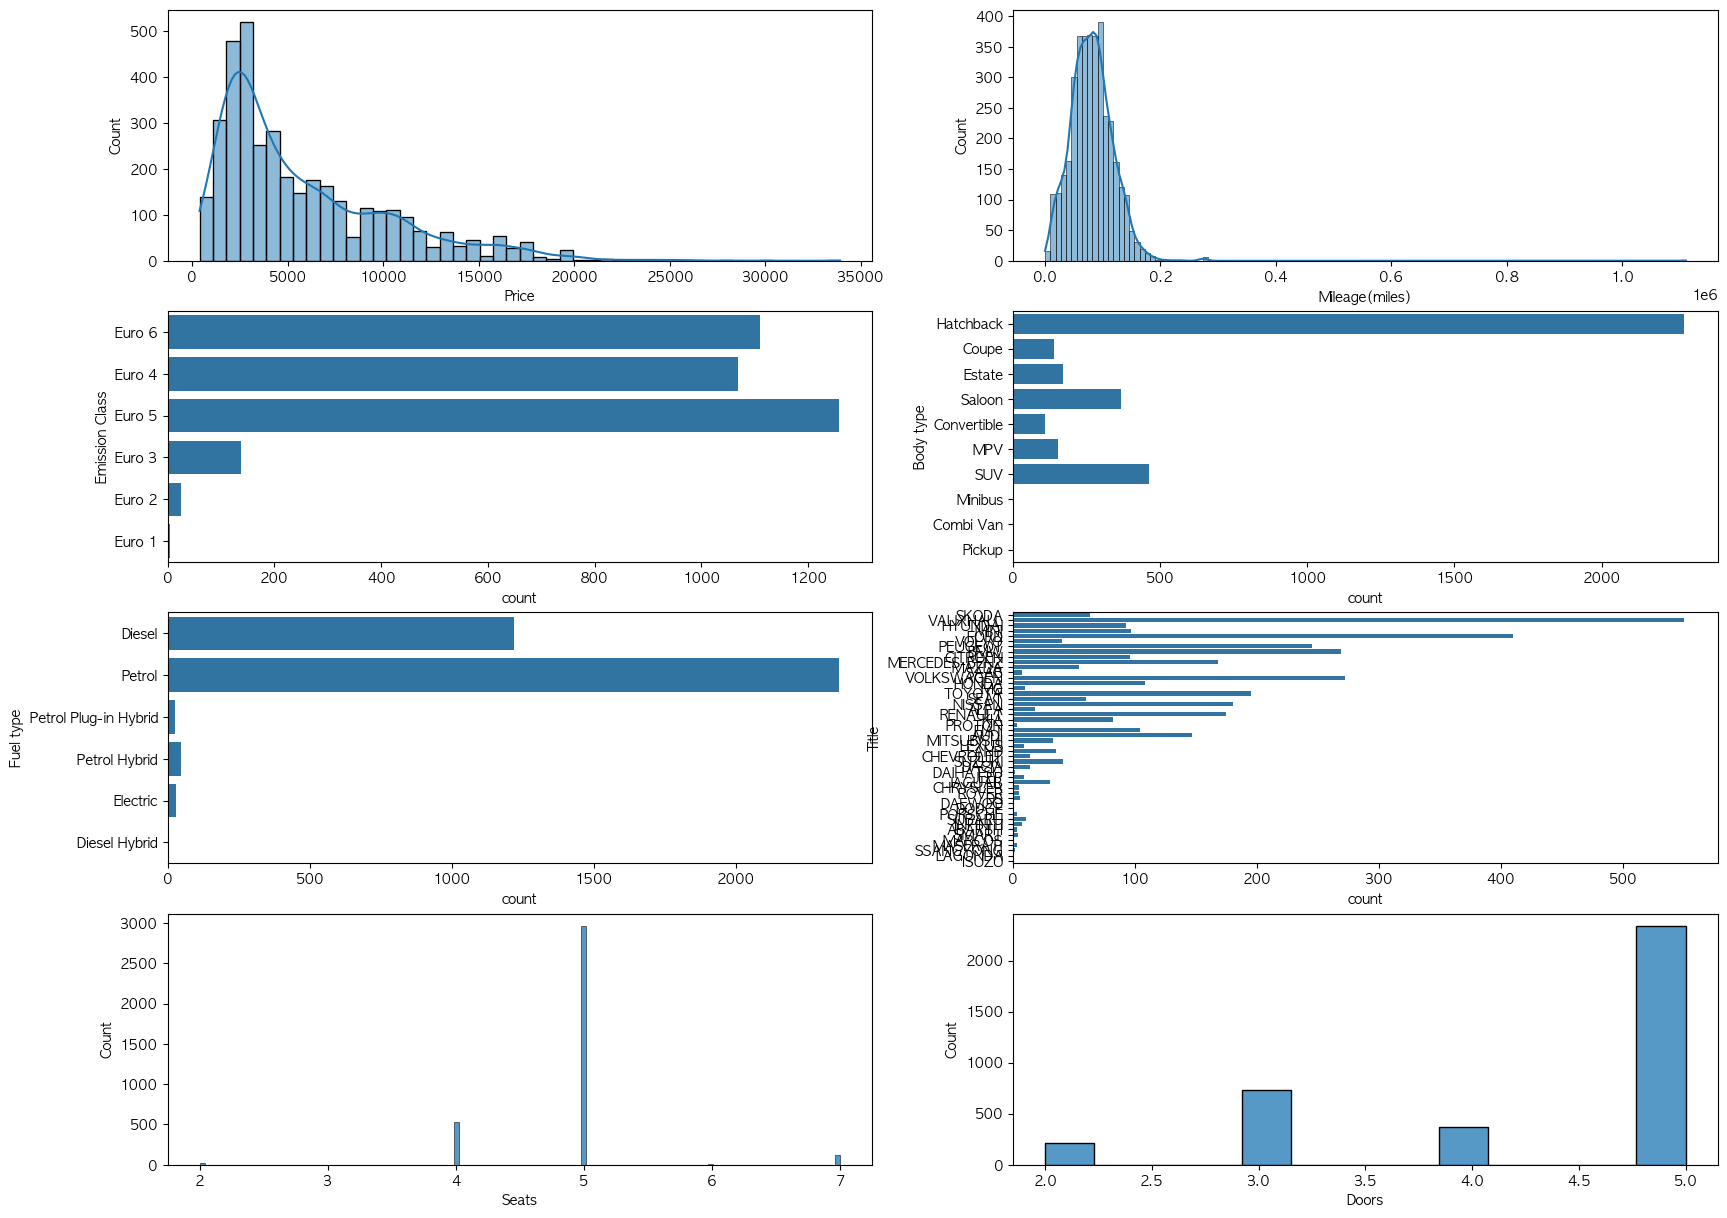

In [361]:
fig, ax = plt.subplots(4,2,figsize=(20,15))
sns.histplot(cars['Price'],ax=ax[0,0],kde=True)
sns.histplot(cars['Mileage(miles)'],ax=ax[0,1],kde=True)
sns.countplot(cars['Emission Class'],ax=ax[1,0]) #4,5,6 등급이 많음
sns.countplot(cars['Body type'],ax=ax[1,1]) # 해치백이 젤 많음
sns.countplot(cars['Fuel type'],ax=ax[2,0]) #페트롤, 디젤이 많음
sns.countplot(cars['Title'],ax=ax[2,1]) #skoda가 젤 많고 그후로 있음
sns.histplot(cars['Seats'],ax=ax[3,0]) #5인승이 젤 많음
sns.histplot(cars['Doors'],ax=ax[3,1]) #5도어가 젤 많음


2. 카테고리형 변수를 숫자 형태로 변환

Engine 이 *.*L 꼴이라 replace 써서 L를 없애주고 데이터 타입 변환

Emission Class도 동일!

In [362]:
#국가별 브랜드, 브랜드별 차 대수 
data.groupby('country')['Title'].value_counts()

country         Title        
Czech Republic  SKODA             63
France          PEUGEOT          245
                RENAULT          175
                CITROEN           96
                DS                 6
Germany         VOLKSWAGEN       272
                BMW              269
                MERCEDES-BENZ    168
                AUDI             147
                SMART              4
                PORSCHE            3
Italy           FIAT             104
                ALFA              18
                ABARTH             3
                MASERATI           3
Japan           TOYOTA           195
                NISSAN           180
                HONDA            108
                MAZDA             54
                SUZUKI            41
                MITSUBISHI        33
                SUBARU            11
                LEXUS              9
                INFINITI           7
                DAIHATSU           2
                ISUZU              1
Malaysia

In [ ]:
#엔진 변수 수치형으로 변환
data['Engine'] = data['Engine'].str.replace('L','',case=False).astype(float)
print(data['Engine'])


#배출 등급도  
data['Emission Class'] = data['Emission Class'].str.replace('Euro','',case=False).astype(float)
print(data['Emission Class'])

0       1.4
1       1.2
2       1.4
3       1.4
4       1.3
       ... 
3682    1.6
3683    2.0
3684    2.0
3685    2.2
3686    1.2
Name: Engine, Length: 3687, dtype: float64
0       6.0
1       4.0
2       5.0
3       4.0
4       5.0
       ... 
3682    4.0
3683    5.0
3684    5.0
3685    4.0
3686    5.0
Name: Emission Class, Length: 3687, dtype: float64


3. 결측치 처리하기
Service history 는 Unknown으로 채우기

나머지는 수치형이라 0으로 채우고 싶지만 그렇게 되면 엔진 용량이런거 0일순 없으니

그냥 drop하기로 결정. 

In [364]:
data['Previous Owners'] = data['Previous Owners'].fillna(0)
data['Service history']= data['Service history'].fillna('Unknown')
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3593 entries, 0 to 3686
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title_x            3593 non-null   object 
 1   Price              3593 non-null   int64  
 2   Mileage(miles)     3593 non-null   int64  
 3   Registration_Year  3593 non-null   int64  
 4   Previous Owners    3593 non-null   float64
 5   Fuel type          3593 non-null   object 
 6   Body type          3593 non-null   object 
 7   Engine             3593 non-null   float64
 8   Gearbox            3593 non-null   object 
 9   Doors              3593 non-null   float64
 10  Seats              3593 non-null   float64
 11  Emission Class     3593 non-null   float64
 12  Service history    3593 non-null   object 
 13  Title              3593 non-null   object 
 14  title_y            3593 non-null   object 
 15  country            3593 non-null   object 
dtypes: float64(5), int64(3), obje

결측치 제거하고 국가까지 만든 data 의 국가별 가격 보기

In [365]:
display(data.groupby('country')['Price'].describe())

,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
Czech Republic,63.0,5569.619048,3347.865138,695.0,2500.00,5999.0,6900.00,20999.0
France,518.0,5482.297297,4257.318394,500.0,1996.00,3995.0,9149.00,24770.0
Germany,842.0,7546.243468,5492.351286,595.0,2995.00,5995.0,10883.75,33900.0
Italy,127.0,4369.952756,3051.636448,640.0,2342.50,3989.0,4972.50,17000.0
Japan,590.0,5238.089831,4022.598607,699.0,2196.00,3495.0,7929.25,23910.0
Malaysia,2.0,1342.500000,498.510281,990.0,1166.25,1342.5,1518.75,1695.0
Romania,14.0,7439.571429,3647.734338,3400.0,5496.00,5997.5,9194.50,14899.0
South Korea,178.0,6275.904494,4179.415668,800.0,2760.00,5295.0,10198.00,20500.0
Spain,59.0,4776.627119,4380.545092,400.0,2799.00,3095.0,5372.00,25995.0


결측치가 존재하는 행 제거는 한 94개정도 했음

### 이상치 분석

PCA에 쫓기느라 이상치를 제대로 파악을 못함

describe 로 간략하게 보면 마일리지, 가격에 거슬리는 이상치가 있는 것 같음

나머지는 그래도 괜찮아 보이는 것으로 판단

거리를 엄청 많이 뛴 이상치 하나만 제거해보는 걸로

,Price,Mileage(miles),Registration_Year,Previous Owners,Engine,Doors,Seats,Emission Class
count,3592.000000,3592.000000,3592.000000,3592.000000,3592.000000,3592.000000,3592.000000,3592.000000
mean,5792.759465,81224.823775,2011.956292,1.747494,1.603062,4.319042,4.898942,4.915367
std,4515.360372,35626.510981,4.739559,1.824062,0.485497,0.986173,0.575252,0.901787
min,400.000000,1.000000,1993.000000,0.000000,0.800000,2.000000,2.000000,1.000000
25%,2490.000000,56984.000000,2008.000000,0.000000,1.300000,3.000000,5.000000,4.000000
50%,3999.500000,80000.000000,2012.000000,1.000000,1.600000,5.000000,5.000000,5.000000
75%,7999.250000,103024.750000,2016.000000,3.000000,1.900000,5.000000,5.000000,6.000000
max,33900.000000,274100.000000,2023.000000,9.000000,6.300000,5.000000,7.000000,6.000000


Text(0.5, 1.0, 'Mileage(miles)')

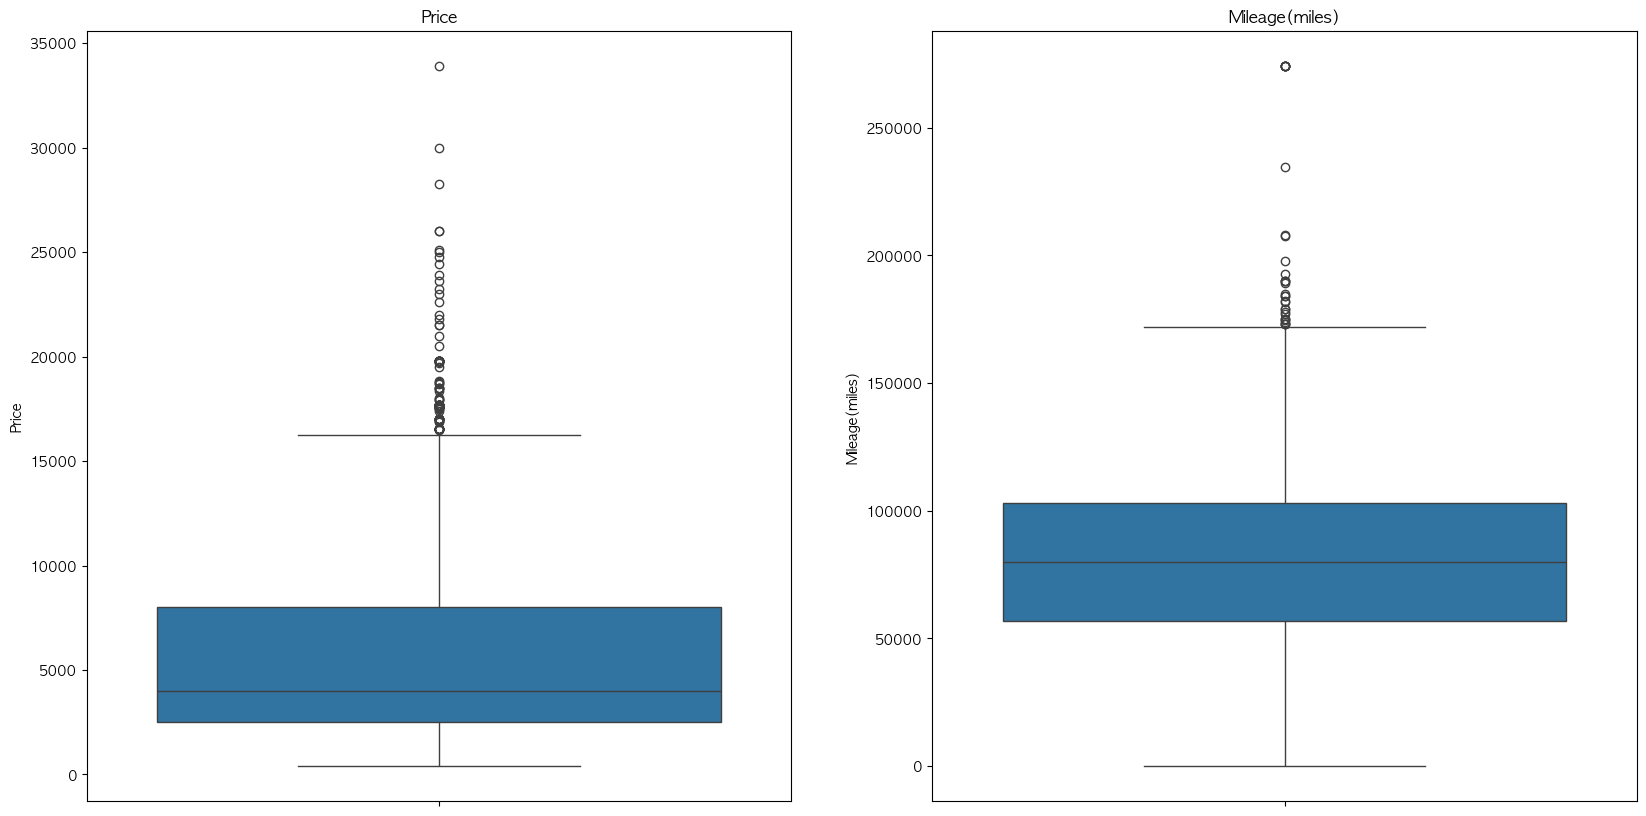

In [423]:
display(data.describe())

data = data.drop(data['Mileage(miles)'].idxmax())
f,ax = plt.subplots(1,2,figsize=(20,10))
sns.boxplot(data['Price'],ax=ax[0])
ax[0].set_title('Price')
sns.boxplot(data['Mileage(miles)'],ax=ax[1])
ax[1].set_title('Mileage(miles)')


### 상관관계 분석

<Axes: >

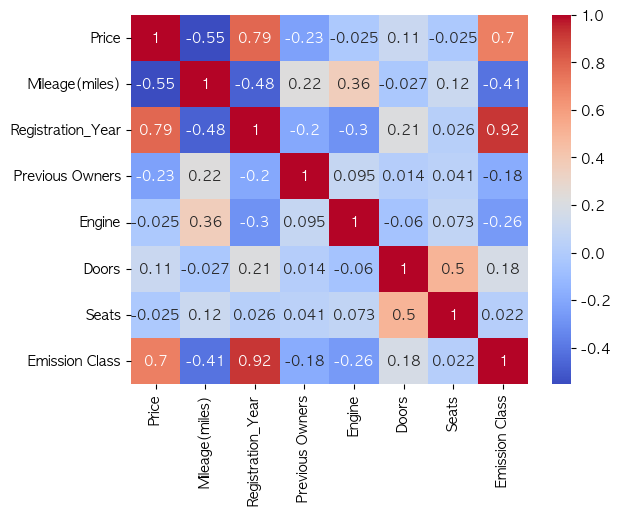

In [424]:
data_numeric = data.select_dtypes(include=[np.number])
sns.heatmap(data_numeric.corr(),annot=True,cmap='coolwarm')

Emission Class 와 price 사이의 강한 양의 상관 (0.7)

Registration_Year 와 Emission Class 의 강한 양의 상관  (0.92)

price 와 Registration_Year의 강한 양의 상관 (0.79) 

가격을 예측한다면 Registration_Year(연식), Emiision Class(배출 등급)

## 가격 예측 PCA 주성분 분석

수치형만 있는 데이터 스케일링 후 주성분 분석 ㄱㄱ

3개의 주성분으로 분산 약 70% 설명 가능 4개로 하면 82% 설명 가능! 뭐가 적당한지는 한번 더 봐야함.

scree plot 으로 elbow method 사용

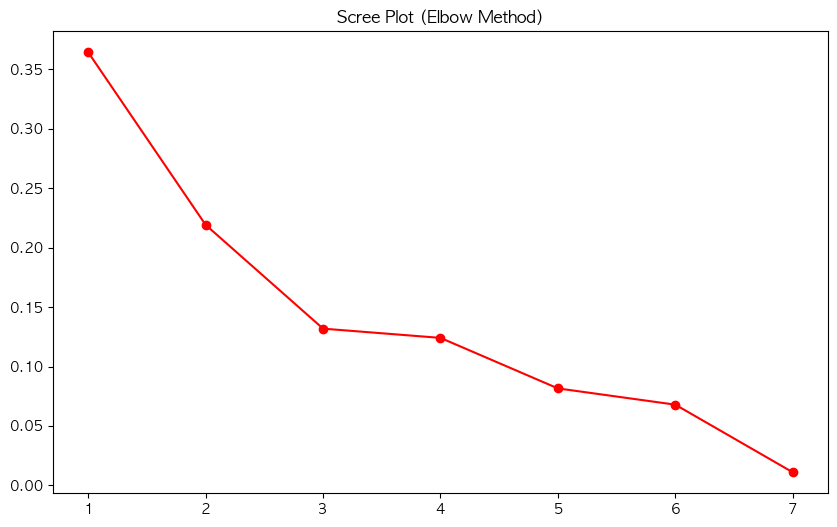

In [425]:
data_noprice = data_numeric.drop('Price',axis=1)

scaler = StandardScaler()
df_scaled = scaler.fit_transform(data_noprice)

pca = PCA()
pca.fit(df_scaled)
exp_var_ratio = pca.explained_variance_ratio_
cumulative_var = np.cumsum(exp_var_ratio)    
plt.figure(figsize=(10, 6))
x_range = range(1, len(exp_var_ratio) + 1)
plt.plot(x_range, exp_var_ratio,'ro-') 
plt.title('Scree Plot (Elbow Method)')
plt.show()

In [426]:
data_scaled = scaler.fit_transform(data_noprice)
pca = PCA(4)

data_pca = pd.DataFrame(pca.fit_transform(data_scaled),columns=['PC1','PC2','PC3','PC4'])
print(pca.explained_variance_ratio_)
print((pca.explained_variance_ratio_).sum())

loadings = pd.DataFrame(pca.components_.T, 
                        columns=['PC1', 'PC2', 'PC3','PC4'], 
                        index=data_noprice.columns)
print(loadings.sort_values(by='PC1', ascending=False))


[0.36441575 0.21919904 0.13186116 0.12407868]
0.8395546305350743
                        PC1       PC2       PC3       PC4
Registration_Year  0.573134  0.045436  0.095489  0.338575
Emission Class     0.553187  0.042427  0.106139  0.404515
Doors              0.165630  0.655110 -0.022837 -0.182525
Seats              0.016757  0.692349 -0.137730 -0.138553
Previous Owners   -0.216473  0.153695  0.935984  0.133289
Engine            -0.322267  0.143129 -0.289898  0.766466
Mileage(miles)    -0.432518  0.208596 -0.004253  0.252954


주성분 해석

- 1번 주성분 : 연식, 등급 -> 차량이 얼마나 최신, 깨끗한지 
- 2번 주성분 : 문개수, 좌석 개수 -> 차량의 공간, 크기
- 3번 주성분 : 명의이전 횟수!
- 4번 주성분 : 엔진 성능

### 가격예측을 위한 주성분 회귀분석 (Principle Component Regression)

가격 ~ 주성분 1 + 주성분 2 + 주성분 3 + 주성분 4

가격에 로그변환도 해보았음. 

In [427]:
data_pca['Price'] = data['Price'].values
data_pca['Log_Price'] = np.log1p(data_pca['Price'])
model1 = smf.ols(formula ='Log_Price ~ PC1 + PC2 +PC3 + PC4',data=data_pca).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:              Log_Price   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.741
Method:                 Least Squares   F-statistic:                     2565.
Date:                Mon, 09 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:37:24   Log-Likelihood:                -1757.7
No. Observations:                3591   AIC:                             3525.
Df Residuals:                    3586   BIC:                             3556.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.3751      0.007   1270.445      0.0

Adj - R^2 0.741 로 모델 설명률이 꽤 좋음 + 모든 주성분의 회귀계수가 모두 유의함!

결과를 보면 PC1 (차량이 얼마나 깨끗한지 등) 와 PC4 (엔진성능)이 가격을 결정하는 핵심요소, 영향력이 큼

PC3(차량의 크기) 와 PC4(소유 이력)이 적어야 가격방어에 유리!

잔차분석으로 등분산성, 정규성 확인까지!

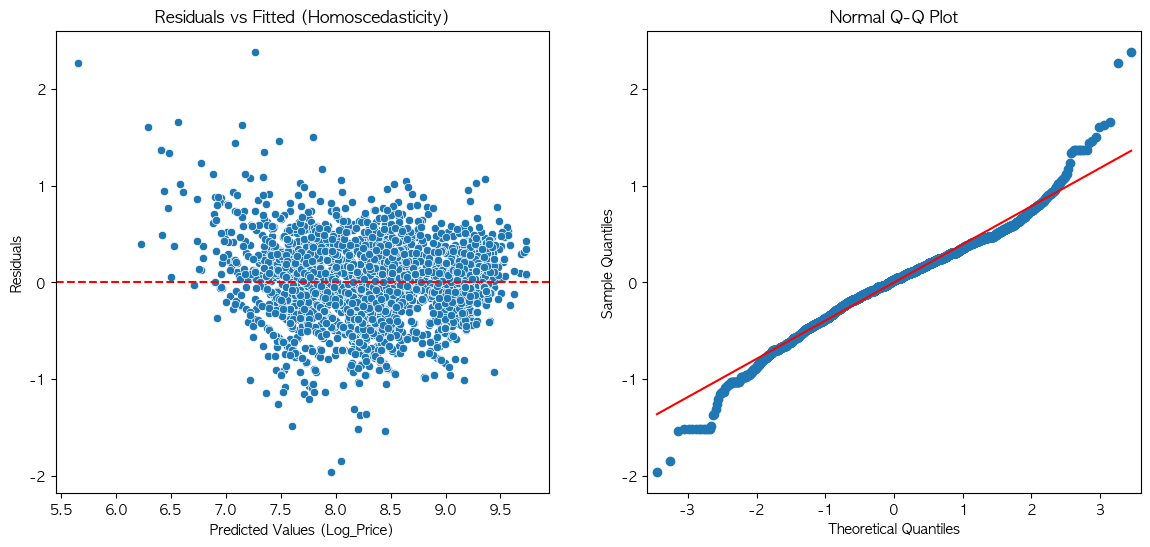

In [430]:
fitted_values = model1.fittedvalues
residuals = model1.resid

plt.figure(figsize=(14, 6))

#Residuals vs Fitted
plt.subplot(1, 2, 1)
sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values (Log_Price)')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted (Homoscedasticity)')

#qqplot
plt.subplot(1, 2, 2)
sm.qqplot(residuals, line='s', ax=plt.gca())
plt.title('Normal Q-Q Plot')

plt.show()

### 더 해볼만 한것

1. test train split도 해서 교차검증 해봐야 좀 더 정확할 것 같음
2. PCA를 할때 범주형을 아예 제외하고 했기 때문에 더미변수 만들어서 예측모델 만들어보면 좋아보임.